![CSDI_Flow_Graph](CSDI_Flow_Graph.PNG)

In [ ]:
import pandas as pd
import geopandas as gpd
import os
import glob

GEOJSON_DIR = r'C:\Users\User\Desktop\CSDI\CSDI\Files\Geojson\ALS_GeoJSON_319'
RESULT_DIR = r'C:\Users\User\Desktop\CSDI\CSDI\Files\Result\v319'
os.makedirs(RESULT_DIR, exist_ok=True)

FINAL_COLUMNS = [
    'CSDI_Northing','CSDI_Easting','CSDI_lat','CSDI_long','CSDI_BuildingID','CSDI_GeoAddress',
    'CSDI_RegionC','CSDI_RegionE','CSDI_DistrictC','CSDI_DistrictE','CSDI_StreetNameC',
    'CSDI_StreetNameE','CSDI_StreetNoFromC','CSDI_StreetNoFromE','CSDI_StreetNoToC',
    'CSDI_StreetNoToE','CSDI_EstateNameC','CSDI_EstateNameE','CSDI_BuildingNameC',
    'CSDI_BuildingNameE','CSDI_BuildingNoC','CSDI_BuildingDescriptorC','CSDI_BuildingNoE',
    'CSDI_BuildingDescriptorE','CSDI_hasBlockSeq','CSDI_PhaseNameC','CSDI_PhaseNameE',
    'CSDI_VillageNameC','CSDI_VillageNameE','CSDI_VillageStreetNoFromC',
    'CSDI_VillageStreetNoFromE','CSDI_VillageStreetNoToC','CSDI_VillageStreetNoToE',
    'CSDI_PhaseNoC','CSDI_PhaseNoE','CSDI_VillageLocationC','CSDI_VillageLocationE',
    'CSDI_StreetLocationC','CSDI_StreetLocationE'
]

COLUMN_MAPPING = {    
    'Northing': 'CSDI_Northing',
    'Easting': 'CSDI_Easting',
    'PremisesAddress.BuildingCsuInformation.CsuId': 'CSDI_BuildingID',
    'PremisesAddress.GeoAddress': 'CSDI_GeoAddress',
    'PremisesAddress.ChiPremisesAddress.Region': 'CSDI_RegionC',
    'PremisesAddress.EngPremisesAddress.Region': 'CSDI_RegionE',
    'PremisesAddress.ChiPremisesAddress.ChiDistrict': 'CSDI_DistrictC',
    'PremisesAddress.EngPremisesAddress.EngDistrict': 'CSDI_DistrictE',
    'PremisesAddress.ChiPremisesAddress.ChiStreet.StreetName': 'CSDI_StreetNameC',
    'PremisesAddress.EngPremisesAddress.EngStreet.StreetName': 'CSDI_StreetNameE',
    'PremisesAddress.ChiPremisesAddress.ChiStreet.BuildingNoFrom': 'CSDI_StreetNoFromC',
    'PremisesAddress.EngPremisesAddress.EngStreet.BuildingNoFrom': 'CSDI_StreetNoFromE',
    'PremisesAddress.ChiPremisesAddress.ChiStreet.BuildingNoTo': 'CSDI_StreetNoToC',
    'PremisesAddress.EngPremisesAddress.EngStreet.BuildingNoTo': 'CSDI_StreetNoToE',
    'PremisesAddress.ChiPremisesAddress.ChiEstate.EstateName': 'CSDI_EstateNameC',
    'PremisesAddress.EngPremisesAddress.EngEstate.EstateName': 'CSDI_EstateNameE',
    'PremisesAddress.ChiPremisesAddress.BuildingName': 'CSDI_BuildingNameC',
    'PremisesAddress.EngPremisesAddress.BuildingName': 'CSDI_BuildingNameE',
    'PremisesAddress.ChiPremisesAddress.ChiBlock.BlockNo': 'CSDI_BuildingNoC',
    'PremisesAddress.ChiPremisesAddress.ChiBlock.BlockDescriptor': 'CSDI_BuildingDescriptorC',
    'PremisesAddress.EngPremisesAddress.EngBlock.BlockNo': 'CSDI_BuildingNoE',
    'PremisesAddress.EngPremisesAddress.EngBlock.BlockDescriptor': 'CSDI_BuildingDescriptorE',
    'PremisesAddress.EngPremisesAddress.EngBlock.BlockDescriptorPrecedenceIndicator': 'CSDI_hasBlockSeq',
    'PremisesAddress.ChiPremisesAddress.ChiEstate.ChiPhase.PhaseName': 'CSDI_PhaseNameC',
    'PremisesAddress.EngPremisesAddress.EngEstate.EngPhase.PhaseName': 'CSDI_PhaseNameE',
    'PremisesAddress.ChiPremisesAddress.ChiVillage.VillageName': 'CSDI_VillageNameC',
    'PremisesAddress.EngPremisesAddress.EngVillage.VillageName': 'CSDI_VillageNameE',
    'PremisesAddress.ChiPremisesAddress.ChiVillage.BuildingNoFrom': 'CSDI_VillageStreetNoFromC',
    'PremisesAddress.EngPremisesAddress.EngVillage.BuildingNoFrom': 'CSDI_VillageStreetNoFromE',
    'PremisesAddress.ChiPremisesAddress.ChiVillage.BuildingNoTo': 'CSDI_VillageStreetNoToC',
    'PremisesAddress.EngPremisesAddress.EngVillage.BuildingNoTo': 'CSDI_VillageStreetNoToE', 
    'PremisesAddress.ChiPremisesAddress.ChiEstate.ChiPhase.PhaseNo': 'CSDI_PhaseNoC',
    'PremisesAddress.EngPremisesAddress.EngEstate.EngPhase.PhaseNo': 'CSDI_PhaseNoE',
    'PremisesAddress.ChiPremisesAddress.ChiVillage.LocationName': 'CSDI_VillageLocationC',
    'PremisesAddress.EngPremisesAddress.EngVillage.LocationName': 'CSDI_VillageLocationE', 
    'PremisesAddress.ChiPremisesAddress.ChiStreet.LocationName': 'CSDI_StreetLocationC',
    'PremisesAddress.EngPremisesAddress.EngStreet.LocationName': 'CSDI_StreetLocationE',
}

geojson_files = glob.glob(os.path.join(GEOJSON_DIR, '*.geojson'))
all_districts = []

print(f"Processing {len(geojson_files)} files...")

for file_path in geojson_files:
    gdf = gpd.read_file(file_path)
    gdf = gdf.dropna(subset=['geometry'])
    gdf_exploded = gdf.explode(index_parts=True).reset_index(drop=True)
    gdf_exploded['CSDI_long'] = gdf_exploded.geometry.x.astype(float)
    gdf_exploded['CSDI_lat'] = gdf_exploded.geometry.y.astype(float)
    address_flat = pd.json_normalize(gdf_exploded['Address'])
    temp_df = pd.concat([gdf_exploded.drop(columns=['Address', 'geometry']), address_flat], axis=1)
    temp_df.rename(columns=COLUMN_MAPPING, inplace=True)
    
    all_districts.append(temp_df)
    print(f"Loaded: {os.path.basename(file_path)}")

if all_districts:
    combined_df = pd.concat(all_districts, ignore_index=True)
    combined_df = combined_df.drop_duplicates()
    final_result_df = combined_df.reindex(columns=FINAL_COLUMNS)
    output_path = os.path.join(RESULT_DIR, 'WCSDI_AddressMaster_v319')
    final_result_df.to_excel(output_path, index=False)
    
    print(f"Total records: {len(final_result_df)}")
    display(final_result_df.head())
else:
    print("No files found.")

Processing 18 files...
Loaded: als_addresses_(central_&_western_district).geojson
Loaded: als_addresses_(eastern_district).geojson
Loaded: als_addresses_(islands_district).geojson
Loaded: als_addresses_(kowloon_city_district).geojson
Loaded: als_addresses_(kwai_tsing_district).geojson
Loaded: als_addresses_(kwun_tong_district).geojson
Loaded: als_addresses_(north_district).geojson
Loaded: als_addresses_(sai_kung_district).geojson
Loaded: als_addresses_(sham_shui_po_district).geojson
Loaded: als_addresses_(sha_tin_district).geojson
Loaded: als_addresses_(southern_district).geojson
Loaded: als_addresses_(tai_po_district).geojson
Loaded: als_addresses_(tsuen_wan_district).geojson
Loaded: als_addresses_(tuen_mun_district).geojson
Loaded: als_addresses_(wan_chai_district).geojson
Loaded: als_addresses_(wong_tai_sin_district).geojson
Loaded: als_addresses_(yau_tsim_mong_district).geojson
Loaded: als_addresses_(yuen_long_district).geojson
Total records: 182620


,CSDI_Northing,CSDI_Easting,CSDI_lat,CSDI_long,CSDI_BuildingID,CSDI_GeoAddress,CSDI_RegionC,CSDI_RegionE,CSDI_DistrictC,CSDI_DistrictE,...,CSDI_VillageStreetNoFromC,CSDI_VillageStreetNoFromE,CSDI_VillageStreetNoToC,CSDI_VillageStreetNoToE,CSDI_PhaseNoC,CSDI_PhaseNoE,CSDI_VillageLocationC,CSDI_VillageLocationE,CSDI_StreetLocationC,CSDI_StreetLocationE
0,816062.0,833501.0,22.28344,114.15002,3350116067T20050430,3350116067T20050430,香港,HK,中西區,CENTRAL & WESTERN DISTRICT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,815940.0,833802.0,22.28234,114.15294,3380315940T20050430,3380315940T20050430,香港,HK,中西區,CENTRAL & WESTERN DISTRICT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,816031.0,833589.0,22.28316,114.15088,3359116031T20050430,3359116031T20050430,香港,HK,中西區,CENTRAL & WESTERN DISTRICT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,815791.0,833654.0,22.28099,114.15151,3365315795T20050430,3365315795T20050430,香港,HK,中西區,CENTRAL & WESTERN DISTRICT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,816328.0,832527.0,22.28584,114.14058,3252816328T20210720,3252816328T20210720,香港,HK,中西區,CENTRAL & WESTERN DISTRICT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


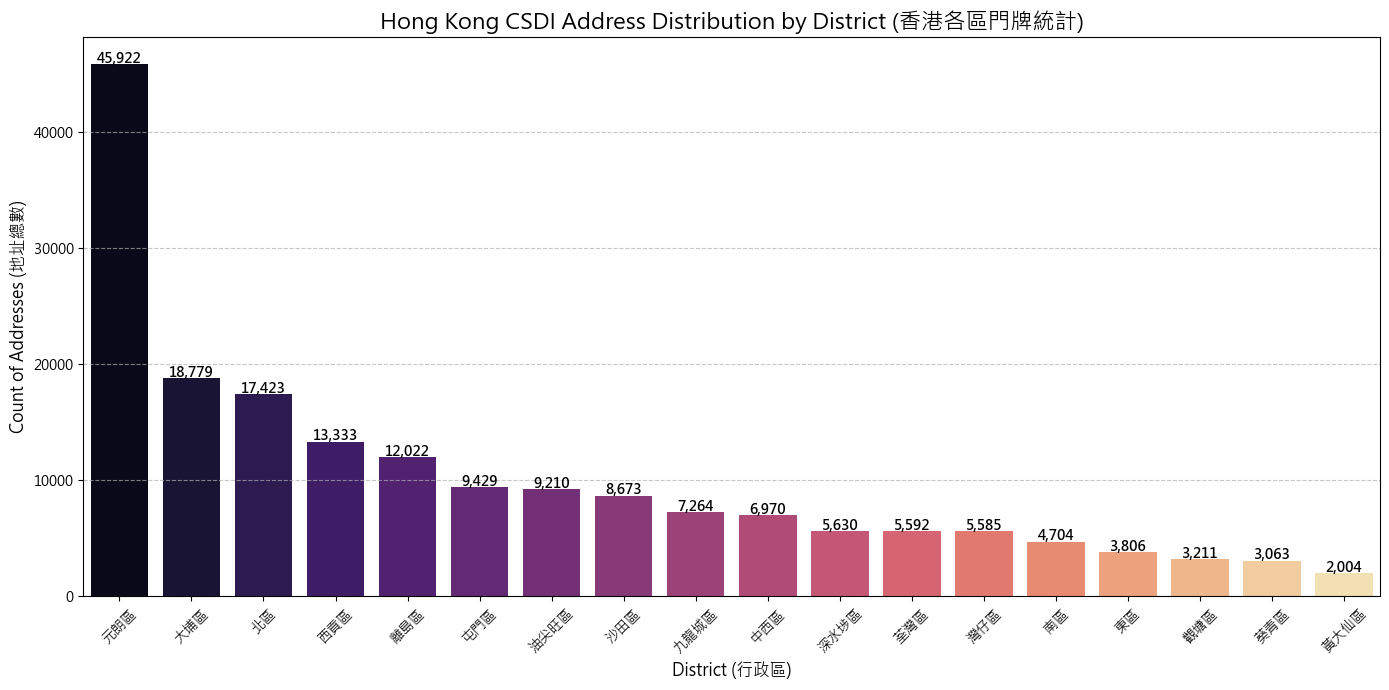

In [4]:
# 1 各區的地址總數

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 
plt.rcParams['axes.unicode_minus'] = False

district_counts = final_result_df['CSDI_DistrictC'].value_counts().sort_values(ascending=False)
    
plt.figure(figsize=(14, 7))
sns.barplot(x=district_counts.index, y=district_counts.values, hue=district_counts.index, palette='magma', legend=False)
    
plt.title('Hong Kong CSDI Address Distribution by District (香港各區門牌統計)', fontsize=16)
plt.xlabel('District (行政區)', fontsize=12)
plt.ylabel('Count of Addresses (地址總數)', fontsize=12)
plt.xticks(rotation=45)
    
for i, v in enumerate(district_counts.values):
    plt.text(i, v + 100, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
    
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

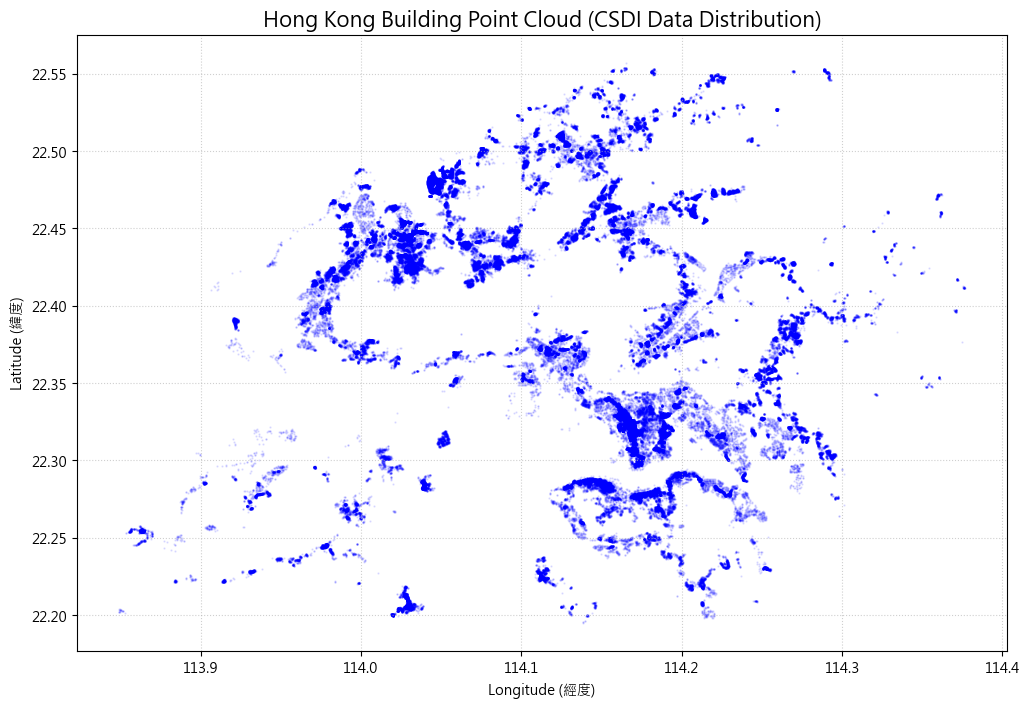

In [5]:
# 2. 哪裡的建築最密集

plt.figure(figsize=(12, 8))
plt.scatter(final_result_df['CSDI_long'], final_result_df['CSDI_lat'], 
            s=0.5, alpha=0.1, c='blue')

plt.title('Hong Kong Building Point Cloud (CSDI Data Distribution)', fontsize=15)
plt.xlabel('Longitude (經度)')
plt.ylabel('Latitude (緯度)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

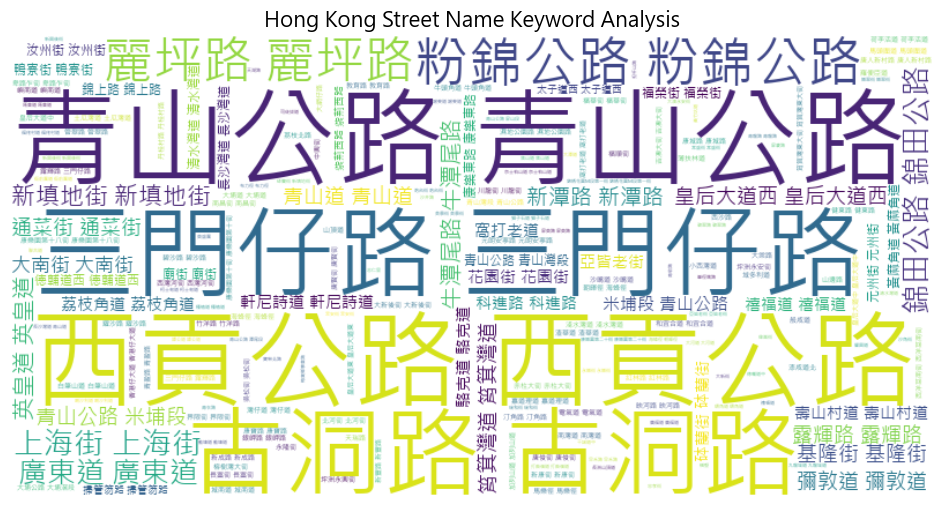

In [6]:
# 3. 哪個街道名稱出現頻率最高

from wordcloud import WordCloud

text = " ".join(str(name) for name in final_result_df['CSDI_StreetNameC'].dropna())
wc = WordCloud(font_path='msjh.ttc', background_color='white', width=800, height=400).generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title('Hong Kong Street Name Keyword Analysis', fontsize=15)
plt.show()